# Upgrading to MindSpore 2.9.0 + CANN 9.0.0 on the OrangePi AIpro \(20T\)

Last time we saw how to upgrade the [MindSpore 2.4.10 + CANN 8.0.0](https://github.com/DonaldKellett/my-ascend-notebooks/blob/735dd25f6cdcb75eefabe25768d7dd337951ae86/orangepiaipro-20t/01-upgrade-cann-mindspore/notebook.ipynb) pre-included with the Ubuntu 22.04 desktop image for [OrangePi AIpro \(20T\)](http://www.orangepi.org/html/hardWare/computerAndMicrocontrollers/details/Orange-Pi-AIpro%2820t%29.html) to MindSpore 2.8.0 + CANN 8.5.0.

MindSpore [2.9.0](https://www.mindspore.cn/docs/en/r2.9.0/RELEASE.html) + CANN [9.0.0](https://www.hiascend.com/document/detail/zh/CANNCommunityEdition/900/releasenote/release-notes.md) were released on May 2026 with the following major highlights, among others.

1. Native support for Ascend 950PR inference-optimized NPUs which the [DeepSeek-V4](https://huggingface.co/collections/deepseek-ai/deepseek-v4) series LLMs were optimized on
1. Addition of 2 DeepSeek Sparse Attention \(DSA\) interfaces under [`mindspore.ops`](https://www.mindspore.cn/docs/en/r2.9.0/api_python/mindspore.ops.html):
    1. `mindspore.ops.sparse_flash_attention`
    1. `mindspore.ops.lightning_indexer`

This notebook article outlines the process of upgrading from MindSpore 2.8.0 + CANN 8.5.0 on the OrangePi AIpro \(20T\) development board to the latest MindSpore 2.9.0 + CANN 9.0.0 as of May 2026. We assume you have already replaced [Conda](https://docs.conda.io/en/latest/) from the provided Ubuntu 22.04 desktop image with [pyenv](https://github.com/pyenv/pyenv) for modern, efficient Python virtual environment management.

## Uninstalling CANN 8.5.0

The steps to uninstall CANN 8.5.0 should be performed _outside_ of any existing Python virtual environment created by pyenv.

The following uninstallation scripts are provided by CANN 8.5.0 which should be executed with the order given below.

1. Uninstalll NNAL: `/usr/local/Ascend/nnal/atb/latest/scripts/uninstall.sh`
1. Uninstall kernels: `/usr/local/Ascend/ascend-toolkit/latest/aarch64-linux/script/ops_uninstall.sh`
1. Uninstall the toolkit library: `/usr/local/Ascend/ascend-toolkit/latest/aarch64-linux/script/uninstall.sh`

These scripts must be run as `root`. Furthermore, if the log file `/var/log/cann_atb_log/cann_atb_install.log` does not already exist, make sure it is created and available as the NNAL uninstallation script expects it at that location.

```bash
sudo mkdir -p /var/log/cann_atb_log/
sudo touch /var/log/cann_atb_log/cann_atb_install.log
```

Now run each uninstallation script with root privileges in order.

```bash
sudo /usr/local/Ascend/nnal/atb/latest/scripts/uninstall.sh
sudo /usr/local/Ascend/ascend-toolkit/latest/aarch64-linux/script/ops_uninstall.sh
sudo /usr/local/Ascend/ascend-toolkit/latest/aarch64-linux/script/uninstall.sh
```

Remember to clear the `/usr/local/Ascend/ascend-toolkit` directory as well.

```bash
sudo rm -rvf /usr/local/Ascend/ascend-toolkit/*
```

## Installing CANN 9.0.0

The steps to install CANN 9.0.0 should be performed _outside_ of any existing Python virtual environment created by pyenv.

Download the following `.run` installers for ARM64 architecture from the [CANN community download page](https://www.hiascend.com/developer/download/community/result?module=cann).

1. Toolkit library: `Ascend-cann-toolkit_9.0.0_linux-aarch64.run`
1. Kernels \(ops\) library for Ascend 310B series NPUs: `Ascend-cann-310b-ops_9.0.0_linux-aarch64.run`
1. Neural network accelerator library \(NNAL\): `Ascend-cann-nnal_9.0.0_linux-aarch64.run`

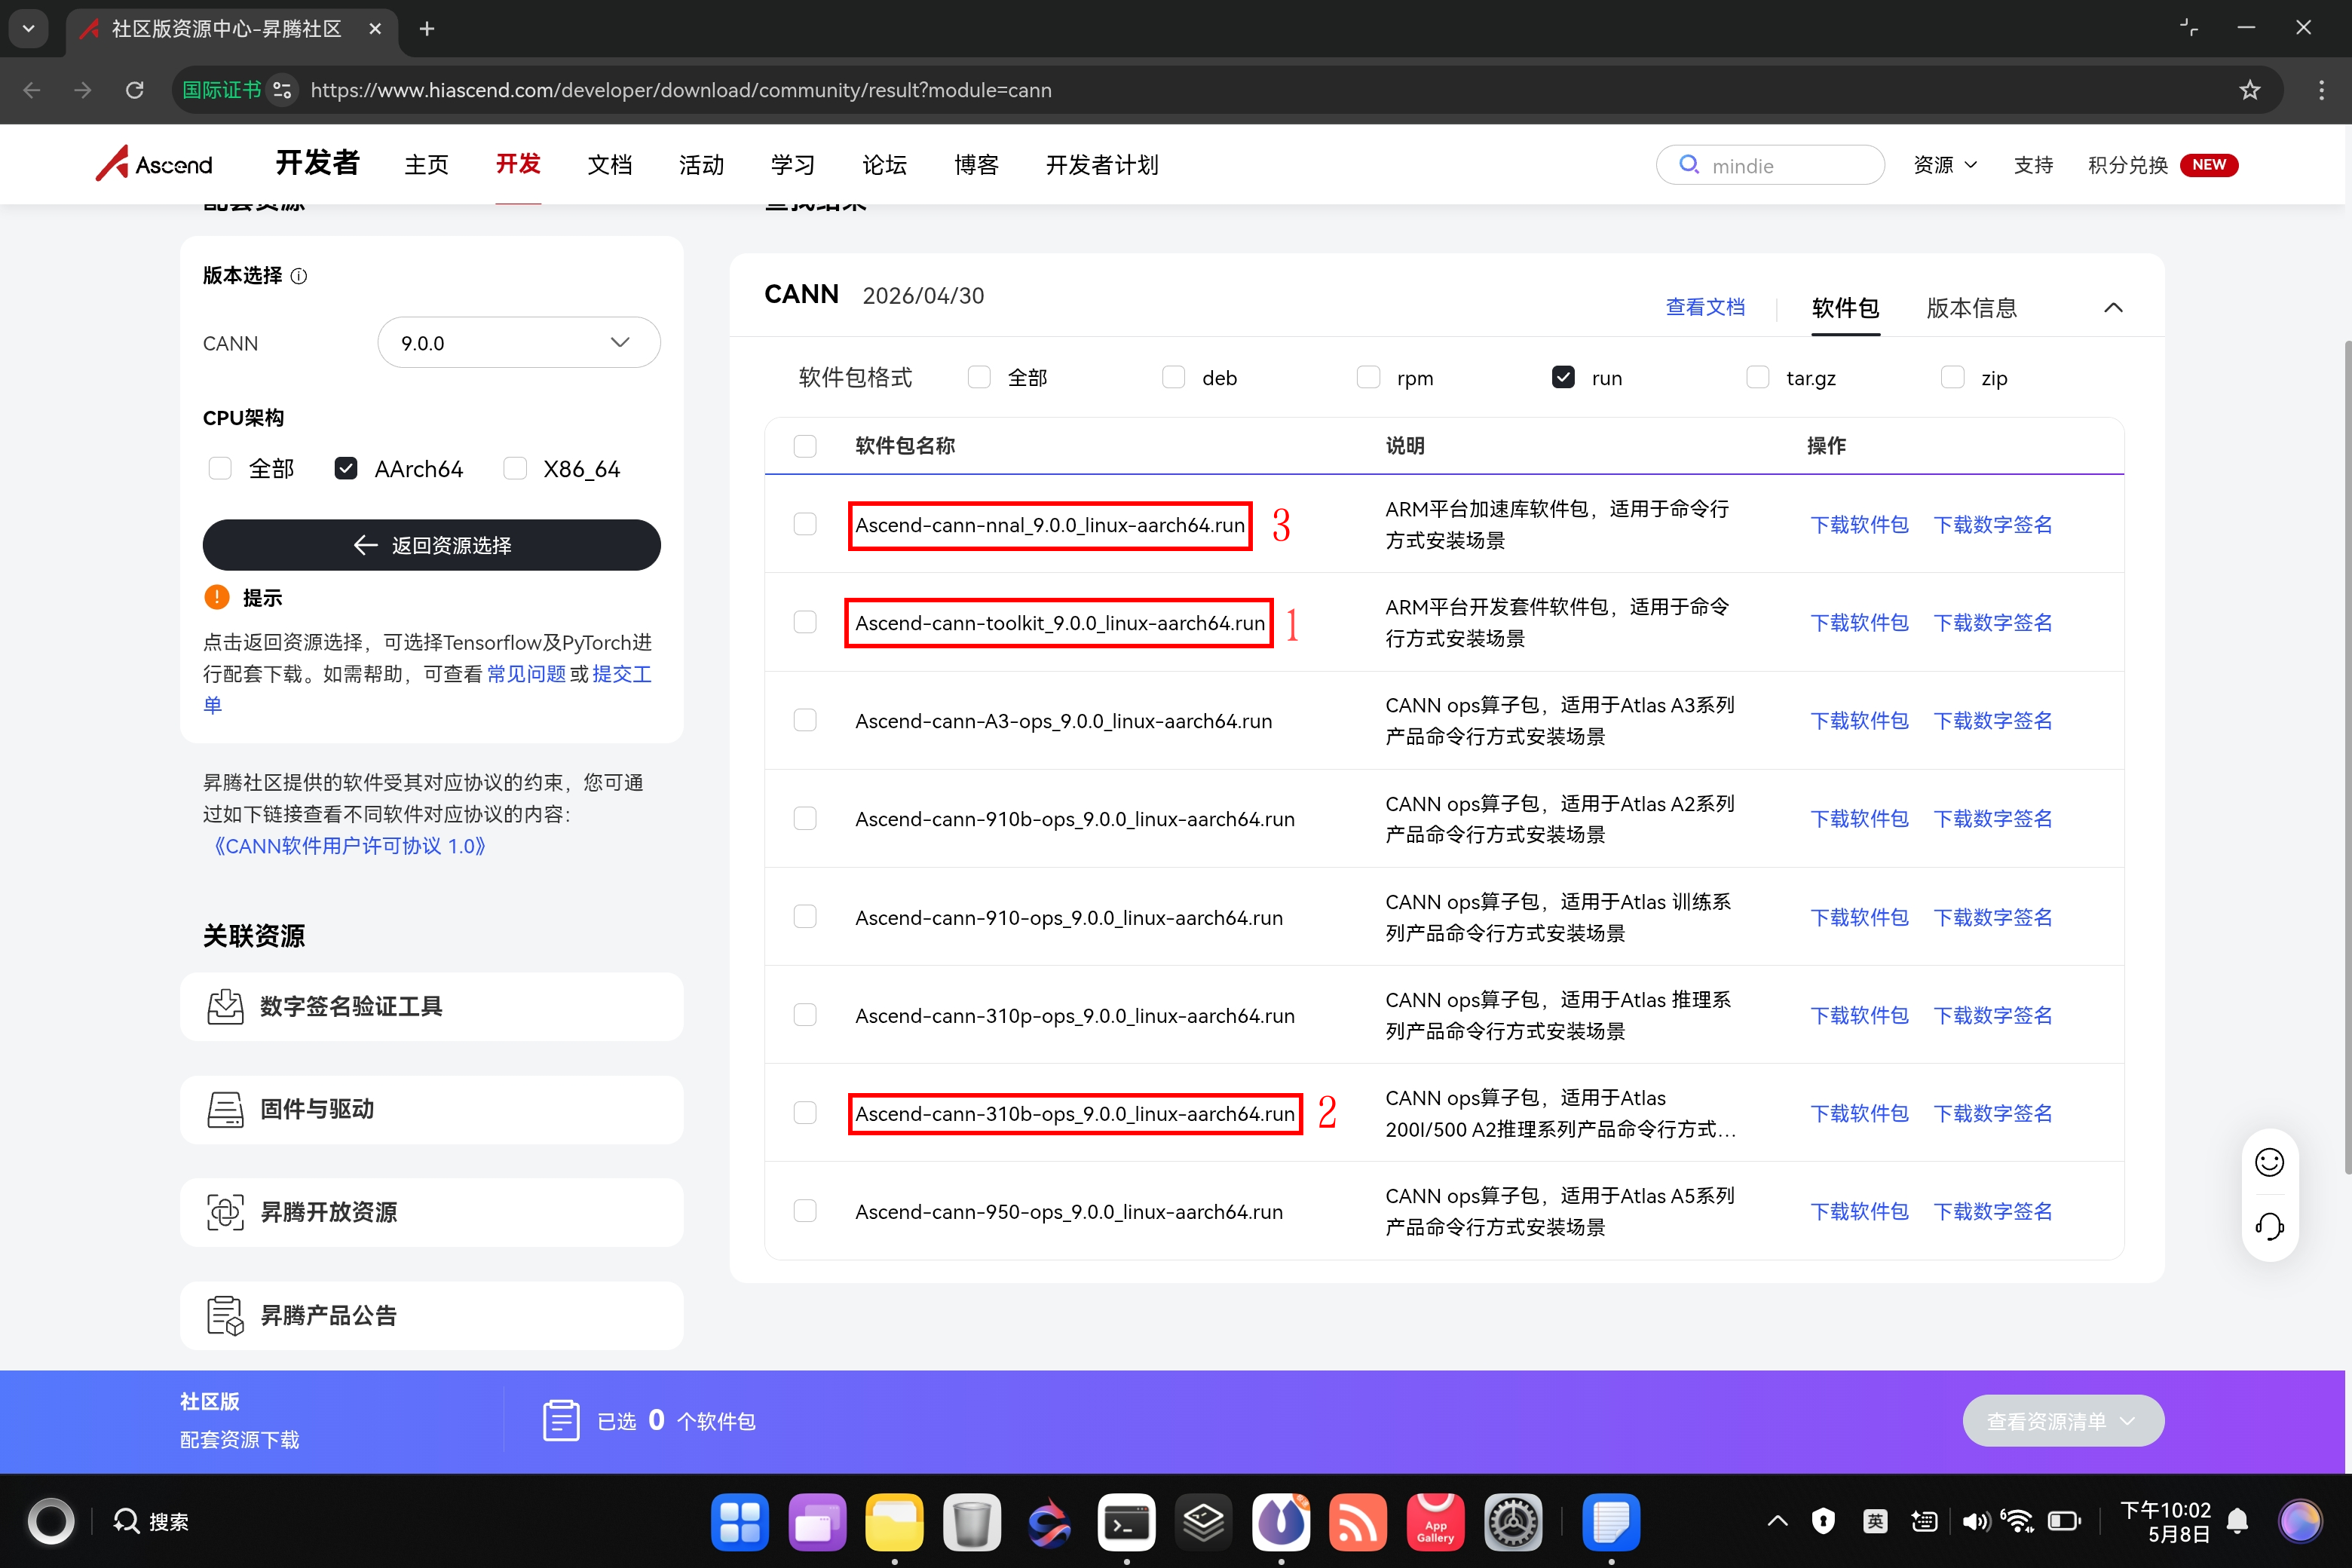

In [1]:
from IPython.display import Image

Image(filename='00-install-cann-900.png')

Now run each installer with root privileges following the order outlined above. For each set of libraries, answer `Y` when prompted to accept the Huawei license agreement.

```bash
sudo ./Ascend-cann-toolkit_9.0.0_linux-aarch64.run --install
sudo ./Ascend-cann-310b-ops_9.0.0_linux-aarch64.run --install
sudo ./Ascend-cann-nnal_9.0.0_linux-aarch64.run --install
```

Once the CANN 9.0.0 libraries are installed, ensure your `~/.bashrc` includes the following lines which sets the environment variables required to use CANN 9.0.0. Restart your shell to take effect.

```bash
source /usr/local/Ascend/cann/set_env.sh
source /usr/local/Ascend/nnal/atb/set_env.sh
```

## Installing MindSpore 2.9.0

The steps to install MindSpore 2.9.0 should be performed _within_ a Python virtual environment created by pyenv. The supported Python versions are Python 3.9 through 3.12. We will use Python 3.12 here as an example.

With CANN 9.0.0 installed and working, let's go ahead and install MindSpore 2.9.0 and dependent packages. The required packages and associated versions are listed below.

In [2]:
!cat requirements.txt

absl-py==2.4.0
attrs==26.1.0
cloudpickle==3.1.2
decorator==5.2.1
jupyterlab==4.5.7
jupyterlab-git==0.53.0
jupyter-resource-usage==1.2.1
loguru==0.7.3
matplotlib==3.10.9
mindspore==2.9.0
ml-dtypes==0.5.4
msguard==0.0.8
openpyxl==3.1.5
opentelemetry-exporter-otlp-proto-grpc==1.33.1
opentelemetry-exporter-otlp-proto-http==1.33.1
pandas~=2.2
plotly>=5.11.0
pydantic==2.13.4
sympy==1.14.0
tornado==6.5.5


Install them with Pip.

In [3]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Now run the verification script below to confirm that MindSpore 2.9.0 is installed successfully. We use [`mindspore.set_device`](https://www.mindspore.cn/docs/en/r2.9.0/api_python/mindspore/mindspore.set_device.html) in place of [`mindspore.set_context`](https://www.mindspore.cn/docs/en/r2.9.0/api_python/mindspore/mindspore.set_context.html) since the latter is deprecated and will be removed in a future version of MindSpore.

In [4]:
import mindspore

mindspore.set_device(device_target='Ascend')
mindspore.run_check()

/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:146: SyntaxWarning: invalid escape sequence '\c'
  2. In forward, tiling would not split c1 and c0, find c1\c0 based on t2.
/usr/local/Ascend/cann-9.0.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:172: SyntaxWarning: invalid escape sequence '\c'
  1. Forward: tiling would not split c1\c0\h0, find c1\c0\h1\h0 based on t2
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangepiaipro-20t/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangep

MindSpore version:  2.9.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!


We can safely ignore any warnings generated as long as there are no lines starting with `[ERROR]` or `[CRITICAL]`, in which case kindly consult the [Ascend forum](https://www.hiascend.com/forum/) for assistance. Usually, absent any hardware issues, such error messages are caused by overly restrictive permissions in the CANN-related directories which can be fixed by relaxing the directory permissions appropriately.

The expected output from a successful MindSpore 2.9.0 installation is repeated below.

```text
MindSpore version: 2.9.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!
```

## Concluding remarks and going further

We saw in this article how to install and use the latest versions of MindSpore and CANN on the OrangePi AIpro \(20T\) development board.

I hope you enjoyed following through this article as much as I did writing it and stay tuned for updates ;-\)